In [1]:
# Multi-protein switch (by DMS_id) + ESM-2 + NGBoost + EI (+diversity)

# =========================
# 0) Setup & Installs
# =========================
!pip -q install fair-esm ngboost

import os, math, random, time
from dataclasses import dataclass
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from scipy.stats import spearmanr, norm

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

from ngboost import NGBRegressor
from ngboost.distns import Normal
from ngboost.scores import MLE

import matplotlib.pyplot as plt

# =========================
# 1) Repro & Config
# =========================
RANDOM_SEED = 6721
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
SHOW_PROGRESS = True

# Select the protein to run by its DMS_id (must exist in REF_PATH)
DMS_ID_TO_RUN = "HMDH_HUMAN_Jiang_2019"

# WT/Meta CSV (must have: DMS_id, target_seq, raw_DMS_directionality)
REF_PATH = "inputs/DMS_substitutions.csv"

# Map each DMS_id to DMS files (sequence, DMS_score)
DMS_ID_TO_FILE = {
    "BLAT_ECOLX_Deng_2012": "inputs/BLAT_ECOLX_Deng_2012.csv",
    "HMDH_HUMAN_Jiang_2019":  "inputs/HMDH_HUMAN_Jiang_2019.csv",
    "RDRP_I33A0_Li_2023":   "inputs/RDRP_I33A0_Li_2023.csv",
}

# ESM model/device
MODEL_FAMILY = "esm2"
ESM_DEVICE   = "cuda"    # "cuda" or "cpu"
ESM_LAYER    = 33        # esm2_t33_650M_UR50D last layer
ESM_BATCH = 64

# Surrogate & features
PCA_DIM    = 32          # PCA on ESM embeddings before NGBoost

# BO / candidate selection
LOW_N      = 96          # seed set size
BATCH_SIZE = 24          # batch per round
N_ROUNDS   = 5           # number of BO rounds
XI         = 0.05        # EI exploration parameter
MIN_HD     = 1           # Hamming diversity (within batch)

# Data / columns
AA_ALPHABET = list("ACDEFGHIKLMNPQRSTVWY")
SEQ_COL     = "mutated_sequence"
RAW_SCORE_COL = "DMS_score"
USE_ZSCORE  = True       # z-score standardization after direction correction
CANDIDATE_POOL_SIZE = None  # cap pool for speed; None = use all

# Output dir
RESULTS_DIR = "outputs"
os.makedirs(RESULTS_DIR, exist_ok=True)


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# =========================
# 2) Helpers
# =========================
@dataclass
class LabeledSeq:
    seq: str
    fitness: float

@dataclass
class Proposal:
    seq: str
    mu: float
    sigma: float
    ei: float

def hamming(s1: str, s2: str) -> int:
    assert len(s1) == len(s2), "Sequences must have the same length"
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

def mean_pairwise_hamming(seqs: List[str]) -> float:
    if len(seqs) < 2: return 0.0
    acc, n = 0, 0
    for i in range(len(seqs)):
        for j in range(i+1, len(seqs)):
            acc += hamming(seqs[i], seqs[j]); n += 1
    return acc / max(n, 1)

def y_of(seqs: List[str], truth_map: dict) -> np.ndarray:
    return np.array([truth_map.get(s, np.nan) for s in seqs], dtype=float)

def topk_true_in_selected(selected: List[str], pool: List[str], truth_map: dict, k: int) -> float:
    pool_sorted = sorted(pool, key=lambda s: truth_map.get(s, -np.inf), reverse=True)
    true_top = set(pool_sorted[:min(k, len(pool_sorted))])
    hit = len(set(selected) & true_top)
    denom = min(k, len(selected))
    return (hit / denom) if denom else 0.0

def expected_improvement(mu, sigma, best_y, xi=0.01):
    imp = mu - best_y - xi
    Z = np.zeros_like(mu)
    nonzero = sigma > 1e-12
    Z[nonzero] = imp[nonzero] / sigma[nonzero]
    ei = np.zeros_like(mu)
    ei[nonzero] = imp[nonzero] * norm.cdf(Z[nonzero]) + sigma[nonzero] * norm.pdf(Z[nonzero])
    return np.maximum(ei, 0.0)

def pick_diverse(proposals: List[Proposal], k: int, min_hd: int) -> List[Proposal]:
    chosen = []
    for p in sorted(proposals, key=lambda x: x.ei, reverse=True):
        if len(chosen) >= k: break
        if (len(chosen) == 0) or all(hamming(p.seq, c.seq) >= min_hd for c in chosen):
            chosen.append(p)
    return chosen[:k]

# =========================
# 3) ESM-2 Embedder
# =========================
class Embedder:
    """ESM-2 (650M) pooled embedding via mean over residues (exclude BOS/EOS)."""
    def __init__(self, family: str = "esm2", device: Optional[str] = None, layer:int=33):
        self.family, self.device, self.layer = family, device, layer
        self._mode = "fallback"
        self._embed_dim = 1280
        self._setup()

    def _setup(self):
        try:
            import torch, esm
            self.torch, self.esm = torch, esm
            if self.family == "esm2":
                model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
                model = model.eval()
                if self.device == "cuda" and torch.cuda.is_available():
                    model = model.to("cuda"); self.device = "cuda"
                else:
                    self.device = "cpu"
                self.model = model
                self.alphabet = alphabet
                self.batch_converter = alphabet.get_batch_converter()
                self._mode = "esm"
            else:
                raise RuntimeError("Only esm2 implemented.")
        except Exception as e:
            print(f"[Embedder] Falling back (no ESM): {e}")
            self._mode = "fallback"
            self.device = "cpu"
            self._rng = np.random.RandomState(RANDOM_SEED)

    def _positional_embed(self, seq: str) -> np.ndarray:
        # Simple fallback: average one-hot projections with random projection per position
        L = len(seq); D = self._embed_dim
        aa_to_idx = {aa:i for i,aa in enumerate(AA_ALPHABET)}
        self._pos_proj = getattr(self, "_pos_proj", None)
        if self._pos_proj is None or self._pos_proj.shape != (L, 20, D):
            self._pos_proj = self._rng.normal(0, 1, size=(L, 20, D)).astype(np.float32)
        out = np.zeros((D,), dtype=np.float32)
        for i, aa in enumerate(seq):
            j = aa_to_idx.get(aa, None)
            if j is not None: out += self._pos_proj[i, j]
        return out / max(L, 1)

    def encode(self, seqs: List[str], batch_size: int = 16) -> np.ndarray:
        if self._mode != "esm":
            it = tqdm(seqs, disable=not SHOW_PROGRESS, desc="Embedding (fallback)")
            return np.vstack([self._positional_embed(s) for s in it])
        embs = []
        batch_size = ESM_BATCH
        with self.torch.no_grad():
            total = math.ceil(len(seqs) / batch_size)
            for start in tqdm(range(0, len(seqs), batch_size),
                              total=total, disable=not SHOW_PROGRESS,
                              desc=f"Embedding (ESM-2)"):
                batch = [("seq", s) for s in seqs[start:start+batch_size]]
                _, _, toks = self.batch_converter(batch)
                toks = toks.to(self.device)
                out = self.model(toks, repr_layers=[ESM_LAYER], return_contacts=False)
                reps = out["representations"][ESM_LAYER]      # [B, L, D]
                pooled = reps[:, 1:-1, :].mean(dim=1).cpu().numpy()  # exclude BOS/EOS
                embs.append(pooled)
        return np.vstack(embs).astype(np.float32, copy=False)

# =========================
# 4) NGBoost Surrogate
# =========================
class NGBSurrogate:
    """Standardize -> PCA -> NGBoost(Normal) → returns (mu, sigma)."""
    def __init__(self, pca_dim: int = 16):
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=pca_dim, random_state=RANDOM_SEED)
        base = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_SEED)
        self.ngb = NGBRegressor(
            Dist=Normal, Base=base, Score=MLE,
            natural_gradient=True, n_estimators=500, learning_rate=0.03,
            random_state=RANDOM_SEED, verbose=False
        )
        self.fitted = False

    def fit(self, X_emb: np.ndarray, y: np.ndarray):
        Z = self.scaler.fit_transform(X_emb.astype(np.float32, copy=False))
        Z = self.pca.fit_transform(Z)
        self.ngb.fit(Z, y.astype(np.float32, copy=False))
        self.fitted = True

    def predict(self, X_emb: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        assert self.fitted
        Z = self.scaler.transform(X_emb.astype(np.float32, copy=False))
        Z = self.pca.transform(Z)
        dist = self.ngb.pred_dist(Z)
        mu, sigma = dist.loc, np.clip(dist.scale, 1e-6, None)
        return mu.astype(np.float32, copy=False), sigma.astype(np.float32, copy=False)

# =========================
# 5) Data loading for chosen DMS_id
# =========================
def load_problem(dms_id: str):
    # Read WT/meta
    ref = pd.read_csv(REF_PATH)
    required_cols = {"DMS_id","target_seq","raw_DMS_directionality"}
    missing = required_cols - set(ref.columns)
    assert not missing, f"WT table missing columns: {missing}"

    row = ref.loc[ref["DMS_id"] == dms_id]
    assert len(row)==1, f"DMS_id '{dms_id}' not found or not unique in {REF_PATH}"
    wt = str(row.iloc[0]["target_seq"]).strip().upper()
    direction = int(row.iloc[0]["raw_DMS_directionality"])  # 1 = higher better, -1 = lower better
    assert direction in (1,-1), f"raw_DMS_directionality must be 1 or -1 for {dms_id}"

    # Map to DMS file
    assert dms_id in DMS_ID_TO_FILE, f"No DMS file mapped for {dms_id} in DMS_ID_TO_FILE"
    dms_path = DMS_ID_TO_FILE[dms_id]
    dms = pd.read_csv(dms_path)

    # basic checks
    assert SEQ_COL in dms.columns and RAW_SCORE_COL in dms.columns, \
        f"DMS file must have columns '{SEQ_COL}' and '{RAW_SCORE_COL}'"

    # clean & filter: valid AA + same length as WT
    valid_aas = set(AA_ALPHABET)
    dms[SEQ_COL] = dms[SEQ_COL].astype(str).str.strip().str.upper()
    def is_valid_seq(s): return (len(s)==len(wt)) and all(ch in valid_aas for ch in s)
    dms = dms[dms[SEQ_COL].map(is_valid_seq)].copy()
    dms = dms[~dms[RAW_SCORE_COL].isna()].copy()

    # direction-aware score: make larger = better
    dms["score_directed"] = dms[RAW_SCORE_COL].astype(float) * float(direction)

    # normalization (z-score across this protein's dataset)
    if USE_ZSCORE:
        mu = dms["score_directed"].mean()
        sd = dms["score_directed"].std(ddof=0) + 1e-8
        dms["fitness"] = (dms["score_directed"] - mu) / sd
    else:
        dms["fitness"] = dms["score_directed"]

    return wt, dms

# =========================
# 6) Build split (96 + pool) for the chosen protein
# =========================
WT, dms = load_problem(DMS_ID_TO_RUN)
print(f"[{DMS_ID_TO_RUN}] WT length = {len(WT)} | DMS rows after cleaning = {len(dms)}")

dms = dms.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
seed96 = dms.iloc[:LOW_N].copy()
pool_df = dms.iloc[LOW_N:].copy()
if CANDIDATE_POOL_SIZE is not None and CANDIDATE_POOL_SIZE < len(pool_df):
    pool_df = pool_df.sample(n=CANDIDATE_POOL_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)

labeled_data = [LabeledSeq(seq=row[SEQ_COL], fitness=float(row["fitness"])) for _, row in seed96.iterrows()]
candidate_pool = pool_df[SEQ_COL].tolist()
truth_map = dict(zip(dms[SEQ_COL], dms["fitness"]))
print(f"Round-0 labeled: {len(labeled_data)} | Candidate pool: {len(candidate_pool)}")

# Save the initial 96
seed96_out = os.path.join(RESULTS_DIR, f"{DMS_ID_TO_RUN}_initial96.csv")
seed96.to_csv(seed96_out, index=False)
print(f"Saved initial 96 → {seed96_out}")

# =========================
# 7) Initialize models
# =========================
embedder = Embedder(family=MODEL_FAMILY, device=ESM_DEVICE, layer=ESM_LAYER)
surrogate = NGBSurrogate(pca_dim=PCA_DIM)
print(f"Embedder mode: {getattr(embedder,'_mode','?')} | device={ESM_DEVICE}")

# ===== Embedding cache (build once) =====
ALL_SEQS = dms[SEQ_COL].tolist()
cache_emb_path = os.path.join(RESULTS_DIR, f"{DMS_ID_TO_RUN}_embeddings.npy")
cache_seqs_path = os.path.join(RESULTS_DIR, f"{DMS_ID_TO_RUN}_embeddings_seqs.csv")

EMB_MAP = None  # will become dict: seq -> embedding (np.float32[1280])

def _build_emb_map_from_arrays(seqs_list, emb_array):
    return {s: e for s, e in zip(seqs_list, emb_array)}

# Try to load from disk first (to avoid recompute on re-runs)
if os.path.exists(cache_emb_path) and os.path.exists(cache_seqs_path):
    saved_seqs = pd.read_csv(cache_seqs_path)["seq"].tolist()
    if saved_seqs == ALL_SEQS:
        E_ALL = np.load(cache_emb_path, mmap_mode=None)
        EMB_MAP = _build_emb_map_from_arrays(ALL_SEQS, E_ALL)
        print(f"[Cache] Loaded embeddings: {E_ALL.shape} from {cache_emb_path}")
    else:
        print("[Cache] Sequence order changed; rebuilding embeddings...")

if EMB_MAP is None:
    # Compute once on GPU
    print("[Cache] Computing ESM embeddings for all sequences...")
    E_ALL = embedder.encode(ALL_SEQS)  # uses ESM_BATCH internally
    E_ALL = E_ALL.astype(np.float32, copy=False)
    EMB_MAP = _build_emb_map_from_arrays(ALL_SEQS, E_ALL)
    np.save(cache_emb_path, E_ALL)
    pd.DataFrame({"seq": ALL_SEQS}).to_csv(cache_seqs_path, index=False)
    print(f"[Cache] Saved embeddings → {cache_emb_path} and {cache_seqs_path}")

def emb_lookup(seq_list: List[str]) -> np.ndarray:
    return np.vstack([EMB_MAP[s] for s in seq_list]).astype(np.float32, copy=False)

# =========================
# 8) BO: propose from pool
# =========================
def propose_from_pool(embedder: Embedder,
                      surrogate: NGBSurrogate,
                      labeled: List[LabeledSeq],
                      candidate_pool: List[str],
                      batch_size: int = 24,
                      xi: float = 0.01,
                      min_hd_between: int = 2) -> List[Proposal]:

    # Train surrogate
    X_train = emb_lookup([x.seq for x in tqdm(labeled, disable=not SHOW_PROGRESS, desc="Embedding labeled (cache)")])
    y_train = np.array([x.fitness for x in labeled], dtype=float)
    surrogate.fit(X_train, y_train)

    # Score pool
    tested = set(x.seq for x in labeled)
    cand = [s for s in candidate_pool if s not in tested]
    if len(cand) == 0: return []

    X_cand = emb_lookup(cand)
    mu, sigma = surrogate.predict(X_cand)
    best_y = float(np.max(y_train))
    ei = expected_improvement(mu, sigma, best_y, xi=xi)

    proposals = [Proposal(seq=c, mu=float(m), sigma=float(s), ei=float(e))
                 for c, m, s, e in zip(cand, mu, sigma, ei)]
    return pick_diverse(sorted(proposals, key=lambda x: x.ei, reverse=True),
                        k=batch_size, min_hd=min_hd_between)

# =========================
# 9) Multi-round BO loop
# =========================
rows = []
measured_set = set(x.seq for x in labeled_data)
all_dms_seqs = list(dms[SEQ_COL])

for r in range(1, N_ROUNDS+1):
    proposals = propose_from_pool(embedder, surrogate, labeled_data, candidate_pool,
                                  batch_size=BATCH_SIZE, xi=XI, min_hd_between=MIN_HD)

    props_df = pd.DataFrame([{
        "seq": p.seq, "mu": p.mu, "sigma": p.sigma, "ei": p.ei, "hd_to_WT": hamming(p.seq, WT)
    } for p in proposals]).sort_values("ei", ascending=False).reset_index(drop=True)

    props_path = os.path.join(RESULTS_DIR, f"{DMS_ID_TO_RUN}_bo_proposals_round{r}.csv")
    props_df.to_csv(props_path, index=False)
    print(f"[Round {r}] Proposed {len(props_df)} → {props_path}")

    # "Measure" against ground-truth fitness (directed+normalized)
    sel = props_df["seq"].tolist()
    measured = [LabeledSeq(seq=s, fitness=float(truth_map[s])) for s in sel if s in truth_map]
    print(f"[Round {r}] Simulated measurements: {len(measured)}")

    # Update sets
    labeled_data += measured
    chosen_set = set(sel)
    candidate_pool = [s for s in candidate_pool if s not in chosen_set]
    measured_set |= chosen_set

    # Metrics per round
    pre_pool = [s for s in all_dms_seqs if s not in (measured_set - chosen_set)]
    y_sel = y_of(sel, truth_map)
    prev_measured = measured_set - chosen_set
    best_prev = float(np.nanmax(y_of(list(prev_measured), truth_map))) if prev_measured else float("nan")
    best_now  = float(np.nanmax(y_of(list(measured_set), truth_map)))
    avg_sel   = float(np.nanmean(y_sel)) if len(y_sel) else float("nan")
    gain_best = best_now - best_prev if not math.isnan(best_prev) else 0.0
    gain_avg  = avg_sel  - best_prev if not math.isnan(best_prev) else 0.0
    div_hd    = mean_pairwise_hamming(sel)

    rho = np.nan
    if "mu" in props_df.columns:
        mask = ~np.isnan(y_sel)
        if mask.sum() >= 2:
            rho = float(spearmanr(props_df.loc[mask, "mu"], y_sel[mask]).correlation)

    rows.append(dict(
        round=r,
        best_so_far=best_now,
        avg_selected=avg_sel,
        gain_best_vs_prev=gain_best,
        gain_avg_vs_prevbest=gain_avg,
        diversity_mean_hamming=div_hd,
        **{
            "Hit@24": topk_true_in_selected(sel, pre_pool, truth_map, k=24),
            "Hit@96": topk_true_in_selected(sel, pre_pool, truth_map, k=96),
            "Spearman(μ,true)": rho
        },
        n_measured_total=len(measured_set)
    ))

# =========================
# 10) Show per-round metrics + plots
# =========================
res_df = pd.DataFrame(rows, columns=[
    "round","best_so_far","avg_selected","gain_best_vs_prev","gain_avg_vs_prevbest",
    "diversity_mean_hamming","Hit@24","Hit@96","Spearman(μ,true)","n_measured_total"
])
from IPython.display import display
display(res_df)

plt.figure()
plt.plot(res_df["round"], res_df["best_so_far"], marker="o")
plt.xlabel("Round"); plt.ylabel("Best so far"); plt.title(f"{DMS_ID_TO_RUN}: Best fitness across rounds"); plt.grid(True); plt.show()

plt.figure()
plt.plot(res_df["round"], res_df["avg_selected"], marker="o")
plt.xlabel("Round"); plt.ylabel("Average of selected"); plt.title(f"{DMS_ID_TO_RUN}: Average selected per round"); plt.grid(True); plt.show()

plt.figure()
plt.plot(res_df["round"], res_df["Hit@24"], marker="o", label="Hit@24")
plt.plot(res_df["round"], res_df["Hit@96"], marker="o", label="Hit@96")
plt.xlabel("Round"); plt.ylabel("Hit rate"); plt.title(f"{DMS_ID_TO_RUN}: Hit@K over rounds"); plt.legend(); plt.grid(True); plt.show()

DMS fitness stats (after direction & z-score):
 mean: -9.31762562172801e-17
 max : 1.9673350761269706
 mode: [-1.5156081925759766]


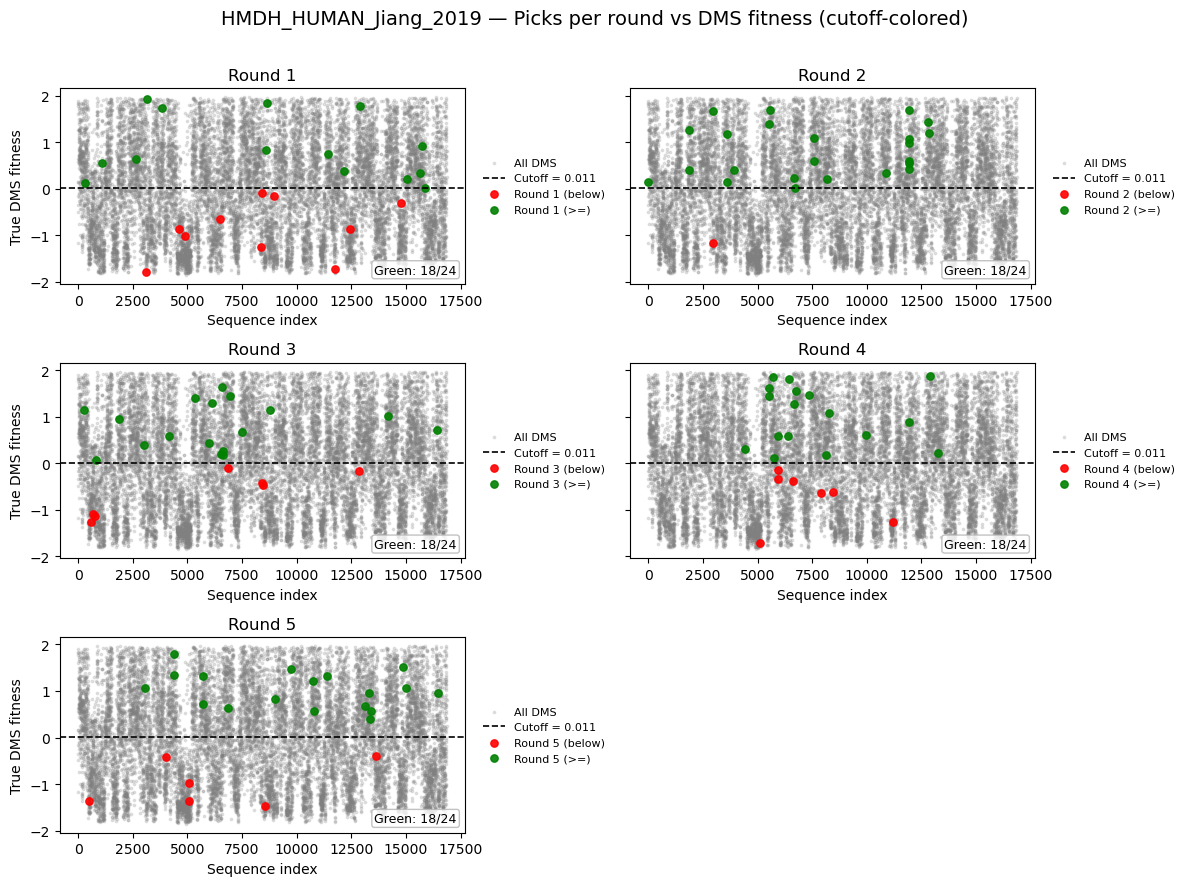

<Figure size 640x480 with 0 Axes>

C:\Users\timap\AppData\Local\Temp\ipykernel_39928\2779809571.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Round", y="Fitness", data=df_sel, palette="viridis")


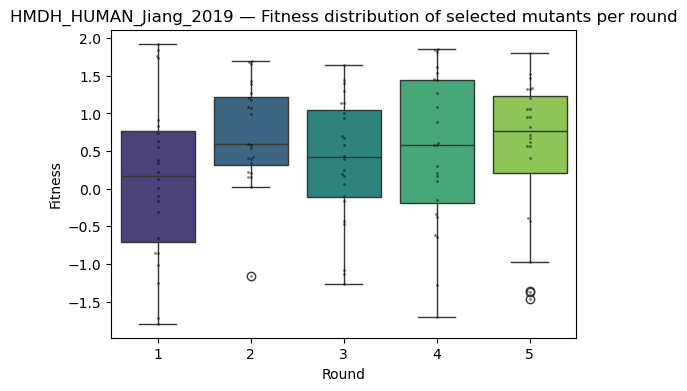

Spearman(μ, true) on proposed set: 0.1898


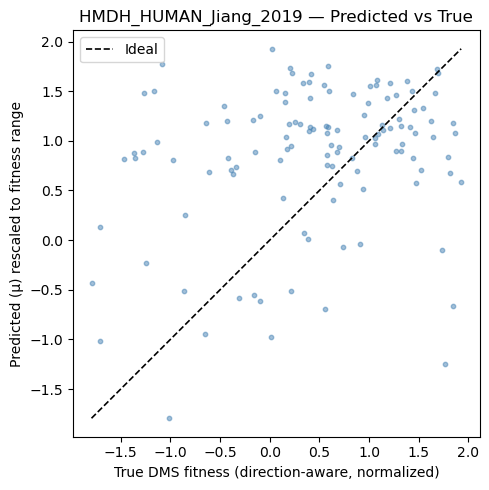

Saved summary → outputs\HMDH_HUMAN_Jiang_2019_summary_rounds_5.csv


In [ ]:
# ==== Analysis / Inspection Cell ====

import os, numpy as np, pandas as pd
from itertools import combinations
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

def load_problem_analysis(dms_id: str):
    ref = pd.read_csv(REF_PATH)
    row = ref.loc[ref["DMS_id"] == dms_id]
    assert len(row)==1, f"DMS_id '{dms_id}' not found or not unique in {REF_PATH}"
    wt = str(row.iloc[0]["target_seq"]).strip().upper()
    direction = int(row.iloc[0]["raw_DMS_directionality"])  # 1=higher better, -1=lower better
    assert direction in (1,-1)

    # try to read cutoff (raw score units) from the reference table
    cutoff_raw = row.iloc[0].get("DMS_binarization_cutoff", np.nan)

    assert dms_id in DMS_ID_TO_FILE, f"No DMS file mapped for {dms_id} in DMS_ID_TO_FILE"
    dms_path = DMS_ID_TO_FILE[dms_id]
    dms = pd.read_csv(dms_path)

    assert SEQ_COL in dms.columns and RAW_SCORE_COL in dms.columns, \
        f"DMS file must have columns '{SEQ_COL}' and '{RAW_SCORE_COL}'"

    valid_aas = set(AA_ALPHABET)
    dms[SEQ_COL] = dms[SEQ_COL].astype(str).str.strip().str.upper()
    def is_valid_seq(s): return (len(s)==len(wt)) and all(ch in valid_aas for ch in s)
    dms = dms[dms[SEQ_COL].map(is_valid_seq)].copy()
    dms = dms[~dms[RAW_SCORE_COL].isna()].copy()

    # Direction-aware score → make larger = better
    dms["score_directed"] = dms[RAW_SCORE_COL].astype(float) * float(direction)

    # Z-score normalization (keep mu/sd for transforming cutoff)
    if USE_ZSCORE:
        mu = dms["score_directed"].mean()
        sd = dms["score_directed"].std(ddof=0) + 1e-8
        dms["fitness"] = (dms["score_directed"] - mu) / sd
    else:
        mu = dms["score_directed"].mean()
        sd = dms["score_directed"].std(ddof=0) + 1e-8
        dms["fitness"] = dms["score_directed"]

    # transform cutoff (raw → direction-aware → plotted fitness space)
    cutoff_fitness = np.nan
    if pd.notna(cutoff_raw):
        cutoff_directed = float(cutoff_raw) * float(direction)
        cutoff_fitness = (cutoff_directed - mu) / sd if USE_ZSCORE else cutoff_directed

    dms = dms.rename(columns={SEQ_COL: "seq"})
    return wt, dms, cutoff_fitness


WT_analysis, dms, cutoff_fitness = load_problem_analysis(DMS_ID_TO_RUN)
truth = dict(zip(dms["seq"], dms["fitness"]))

def y_of(seqs): 
    return np.array([truth.get(s, np.nan) for s in seqs], dtype=float)

# === Load outputs ===
seed_path = os.path.join(RESULTS_DIR, f"{DMS_ID_TO_RUN}_initial96.csv")
seed96 = pd.read_csv(seed_path).rename(columns={SEQ_COL: "seq"})
seed96 = seed96[["seq","fitness"]] if "fitness" in seed96.columns else seed96[["seq"]]

# Load proposal files that exist (1..N_ROUNDS)
props_list = []
for r in range(1, N_ROUNDS+1):
    pth = os.path.join(RESULTS_DIR, f"{DMS_ID_TO_RUN}_bo_proposals_round{r}.csv")
    if os.path.exists(pth):
        df = pd.read_csv(pth)[["seq","mu","sigma","ei","hd_to_WT"]]
        df["round"] = r
        props_list.append(df)
props = props_list

round_dfs = {}
for i, df in enumerate(props_list, start=1):
    round_dfs[i] = df

# === Reconstruct pools ===
measured_r0 = set(seed96["seq"])
pools = {}
sels  = {}

# Round 1
pools[1] = [s for s in dms["seq"] if s not in measured_r0]
sels[1]  = round_dfs[1]["seq"].tolist() if 1 in round_dfs else []
measured_r1 = measured_r0 | set(sels[1])

# Round 2
pools[2] = [s for s in dms["seq"] if s not in measured_r1]
sels[2]  = round_dfs[2]["seq"].tolist() if 2 in round_dfs else []
measured_r2 = measured_r1 | set(sels[2])

# Round 3
pools[3] = [s for s in dms["seq"] if s not in measured_r2]
sels[3]  = round_dfs[3]["seq"].tolist() if 3 in round_dfs else []
measured_r3 = measured_r2 | set(sels[3])

# Round 4
pools[4] = [s for s in dms["seq"] if s not in measured_r3]
sels[4]  = round_dfs[4]["seq"].tolist() if 4 in round_dfs else []
measured_r4 = measured_r3 | set(sels[4])   # <-- fixed (your example mistakenly used sel_r2 here)

# Round 5
pools[5] = [s for s in dms["seq"] if s not in measured_r4]
sels[5]  = round_dfs[5]["seq"].tolist() if 5 in round_dfs else []

# Display quick sanity stats
print("DMS fitness stats (after direction & z-score):")
print(" mean:", float(dms["fitness"].mean()))
print(" max :", float(dms["fitness"].max()))
print(" mode:", dms["fitness"].mode().tolist()[:3])

# === 3) Scatter plots: picked per round on top of full landscape (with cutoff coloring) ===
rounds_for_plot = [sels.get(i, []) for i in range(1, N_ROUNDS+1)]
rows = int(np.ceil((N_ROUNDS)/2))
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 3.0*rows), sharey=True)
axes = np.array(axes).reshape(-1)

for i in range(N_ROUNDS):
    ax = axes[i]
    sel = rounds_for_plot[i] if i < len(rounds_for_plot) else []

    # all DMS background
    ax.scatter(range(len(dms)), dms["fitness"], s=3, alpha=0.2, color="gray", label="All DMS")

    # add cutoff line if available
    if pd.notna(cutoff_fitness):
        ax.axhline(y=cutoff_fitness, linestyle='--', linewidth=1.2, color='k',
                   label=f"Cutoff = {cutoff_fitness:.3f}")

    # selected for this round → split by cutoff and color
    if len(sel):
        sel_idx = dms.index[dms["seq"].isin(sel)]
        y_sel = dms.loc[sel_idx, "fitness"].to_numpy()

        if pd.notna(cutoff_fitness):
            is_green = (y_sel >= cutoff_fitness)
        else:
            # fallback (no cutoff): treat all as red for visibility
            is_green = np.array([False]*len(y_sel))

        # plot reds (below cutoff)
        if (~is_green).any():
            ax.scatter(sel_idx[~is_green], y_sel[~is_green], s=28, alpha=0.9, color="red", label=f"Round {i+1} (below)")
        # plot greens (>= cutoff)
        if (is_green).any():
            ax.scatter(sel_idx[is_green], y_sel[is_green], s=28, alpha=0.9, color="green", label=f"Round {i+1} (>=)")

        # count greens
        green_cnt = int(is_green.sum())
        ax.text(0.98, 0.04, f"Green: {green_cnt}/{len(y_sel)}",
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2",
                  fc="white", ec="0.7", alpha=0.8))


    ax.set_title(f"Round {i+1}")
    if (i % 2) == 0:
        ax.set_ylabel("True DMS fitness")
    ax.set_xlabel("Sequence index")
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)

# Hide any unused subplots
for j in range(N_ROUNDS, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"{DMS_ID_TO_RUN} — Picks per round vs DMS fitness (cutoff-colored)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# Hide any unused subplots
for j in range(len(axes)):
    if j >= N_ROUNDS:
        axes[j].set_visible(False)


fig.suptitle(f"{DMS_ID_TO_RUN} — Picked mutants per round vs full DMS fitness", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# === 4) Box + swarm plot per round ===
try:
    import seaborn as sns
    sel_data = []
    for i in range(1, N_ROUNDS+1):
        sel = sels.get(i, [])
        vals = dms.loc[dms["seq"].isin(sel), "fitness"]
        sel_data.append(pd.DataFrame({"Round": [i]*len(vals), "Fitness": vals}))
    if len(sel_data):
        df_sel = pd.concat(sel_data, ignore_index=True)
        plt.figure(figsize=(6,4))
        sns.boxplot(x="Round", y="Fitness", data=df_sel, palette="viridis")
        sns.swarmplot(x="Round", y="Fitness", data=df_sel, color="k", size=2, alpha=0.5)
        plt.title(f"{DMS_ID_TO_RUN} — Fitness distribution of selected mutants per round")
        plt.show()
except Exception as e:
    print(f"[Warn] seaborn plot skipped: {e}")

# === 5) Predicted vs True (rescaled) ===
# Combine proposals from all rounds, keep first prediction per sequence
if len(props_list):
    props_all = pd.concat(props_list, ignore_index=True)
    pred_df = props_all[["seq","mu"]].drop_duplicates(subset="seq").rename(columns={"mu": "pred_score"})
    merged = dms.merge(pred_df, on="seq", how="inner")

    if len(merged) >= 2:
        pred_min, pred_max = merged["pred_score"].min(), merged["pred_score"].max()
        fit_min, fit_max   = merged["fitness"].min(), merged["fitness"].max()
        # Rescale predictions to same numeric range for visualization
        merged["pred_rescaled"] = (merged["pred_score"] - pred_min) / max(1e-12, (pred_max - pred_min)) * (fit_max - fit_min) + fit_min

        # Spearman correlation (μ vs true)
        rho = spearmanr(merged["pred_score"], merged["fitness"]).correlation
        print(f"Spearman(μ, true) on proposed set: {rho:.4f}")

        plt.figure(figsize=(5,5))
        plt.scatter(merged["fitness"], merged["pred_rescaled"], s=10, alpha=0.5, color="steelblue")
        plt.plot([fit_min, fit_max], [fit_min, fit_max], 'k--', lw=1.2, label="Ideal")
        plt.xlabel("True DMS fitness (direction-aware, normalized)")
        plt.ylabel("Predicted (μ) rescaled to fitness range")
        plt.title(f"{DMS_ID_TO_RUN} — Predicted vs True")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough merged points to draw Predicted vs True plot.")
else:
    print("No proposal files found to build Predicted vs True plot.")

# === Build & save a summary CSV ===
def hit_at_k(selected, pool, truth_map, k):
    pool_sorted = sorted(pool, key=lambda s: truth_map.get(s, -np.inf), reverse=True)
    true_top = set(pool_sorted[:min(k, len(pool_sorted))])
    sel_set  = set(selected)
    denom = min(k, len(selected)) if selected else 1
    return len(sel_set & true_top)/denom

summary_rows = []
measured_set = set(seed96["seq"])
all_dms_seqs = list(dms["seq"])

for r in range(1, N_ROUNDS+1):
    sel = sels.get(r, [])
    pre_pool = [s for s in all_dms_seqs if s not in measured_set]
    y_sel = y_of(sel)
    best_prev = np.nanmax(y_of(list(measured_set))) if len(measured_set) else np.nan
    measured_set |= set(sel)
    best_now  = np.nanmax(y_of(list(measured_set))) if len(measured_set) else np.nan
    avg_sel   = np.nanmean(y_sel) if len(y_sel) else np.nan
    gain_best = (best_now - best_prev) if not np.isnan(best_prev) else np.nan
    gain_avg  = (avg_sel  - best_prev) if not np.isnan(best_prev) else np.nan
    div_hd    = 0.0
    if len(sel) >= 2:
        # mean pairwise Hamming among selected
        from itertools import combinations
        hd_sum = 0; cnt=0
        for a,b in combinations(sel, 2):
            hd_sum += sum(c1 != c2 for c1,c2 in zip(a,b)); cnt += 1
        div_hd = hd_sum / max(cnt,1)

    # Spearman between μ and true on that round’s selected set
    rho_r = np.nan
    if r in round_dfs:
        df_r = round_dfs[r]
        vals = df_r.merge(dms[["seq","fitness"]], on="seq", how="left")
        if vals["fitness"].notna().sum() >= 2:
            rho_r = spearmanr(vals["mu"], vals["fitness"]).correlation

    summary_rows.append(dict(
        round=r,
        best_so_far=best_now,
        avg_selected=avg_sel,
        gain_best_vs_prev=gain_best,
        gain_avg_vs_prevbest=gain_avg,
        diversity_mean_hamming=div_hd,
        **{
            "Hit@24": hit_at_k(sel, pre_pool, truth, 24),
            "Hit@96": hit_at_k(sel, pre_pool, truth, 96),
            "Spearman(μ,true)": rho_r
        },
        n_measured_total=len(measured_set)
    ))

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(RESULTS_DIR, f"{DMS_ID_TO_RUN}_summary_rounds_{len(summary_rows)}.csv")
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary → {summary_path}")
